# 06 — Rejim stres testi (Faz C.5.1)

**Plan:** `LAGO_BENCHMARK_PLAN.md` Faz C.5

Soru: **rejim adaptivitesi model sınıfından mı, eğitim-penceresi politikasından mı,
özelliklerden mi geliyor?** İki rejim dilimi:

| Dilim | Dönem | Zorluk |
|---|---|---|
| **Spike** | 2022 tam yıl | Küresel enerji krizi, tavan kenetlenmesi. Canlı model bunu HİÇ görmedi |
| **Çöküş** | 2026-02-01 → 06-30 (150g) | Yenilenebilir/hidro bolluğu, sıfır-fiyat |

Modeller: LEAR ailesi (yuvarlanan kalibrasyon, bizim impl + epftoolbox) · canlı LightGBM
(`gold.ptf_predictions_daily`) · **WF-LightGBM** (canlı `lgb_lag0_v2`, `run_wf_lightgbm.py`,
proxy'siz) eğitim 2021 vs 2023 · **LightGBM ensemble** (C.5.3', 90/150/tüm) · naive-2/3.


In [1]:
import sys, os
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT = Path.cwd().parents[2]; sys.path.insert(0, str(ROOT))
from src.eval import lago_protocol as lp
from sqlalchemy import text
from db.connection import get_db_engine
H = Path.cwd()
REF_CWS = [56, 84, 1092, 1456]; TR4 = [56, 180, 1092, 1456]
SPIKE_CWS = [56, 84, 120, 180, 545, 730]  # cw1092/1456: 2017-18 verisi yok
pd.set_option('display.width', 170)

def dblock(s):
    s = s.dropna(); idx = s.index
    if getattr(idx,'tz',None) is not None: idx = idx.tz_convert('Europe/Istanbul').tz_localize(None)
    w = pd.DataFrame({'v': s.to_numpy()}, index=idx)
    w['d']=w.index.normalize(); w['h']=w.index.hour
    return w.pivot_table(index='d',columns='h',values='v',aggfunc='first').reindex(columns=range(24)).set_axis([f'h{h:02d}' for h in range(24)],axis=1)


In [2]:
px = pd.read_csv(H/'tr_epf_ext.csv', index_col=0, parse_dates=True)['Price']
y  = dblock(px); n2 = dblock(lp.naive_forecast(px,2)); n3 = dblock(lp.naive_forecast(px,3))

our_long = {int(f.split('cw')[1].split('.')[0]): pd.read_csv(H/f, index_col=0, parse_dates=True)
            for f in os.listdir(H) if f.startswith('ours_lear_cw') and '_spike' not in f and 'cw28' not in f}
ref = {cw: pd.read_csv(H/f'lago_ref_lear_cw{cw}.csv', index_col=0, parse_dates=True) for cw in REF_CWS}
our_spike = {int(f.split('cw')[1].split('_')[0]): pd.read_csv(H/f, index_col=0, parse_dates=True)
             for f in os.listdir(H) if f.startswith('ours_lear_cw') and '_spike' in f}

lg = pd.read_sql(text('SELECT target_ts ts, predicted_mcp_usd v FROM gold.ptf_predictions_daily WHERE predicted_mcp_usd IS NOT NULL'), get_db_engine())
lg['ts'] = pd.to_datetime(lg.ts); lgb_live = dblock(lg.set_index('ts').v)

wf = {}
for f in os.listdir(H):
    if f.startswith('wf_lgbm_'): wf[f[8:-4]] = pd.read_csv(H/f, index_col=0, parse_dates=True)
print('LEAR uzun:', sorted(our_long), '| LEAR spike:', sorted(our_spike))
print('WF-LightGBM:', sorted(wf))


# --- LightGBM çok-pencereli ensemble (C.5.3', proxy'siz WF _v2) ---
def _mw(*keys):
    ds = [wf[k].copy() for k in keys]
    for d in ds: d.columns = [f'h{h:02d}' for h in range(24)]
    return sum(ds) / len(ds)
lgb_ens_cok   = _mw('bt2y_v2_base', 'bt2y_v2_roll90', 'bt2y_v2_roll150')   # çöküş dilimini kapsıyor
lgb_ens_spike = _mw('enssp_v2_base', 'enssp_v2_r90', 'enssp_v2_r150')      # 2022
print('ensemble çöküş:', lgb_ens_cok.dropna(how="all").index.min().date(), '->', lgb_ens_cok.dropna(how="all").index.max().date())


LEAR uzun: [56, 84, 120, 180, 270, 365, 545, 730, 1092, 1456] | LEAR spike: [56, 84, 120, 180, 545, 730]
WF-LightGBM: ['DIAG_cokus_base', 'DIAG_cokus_roll150', 'DIAG_cokus_roll90', 'DIAG_noproxy', 'DIAG_noproxy_roll150', 'DIAG_noproxy_roll90', 'bt2y_base', 'bt2y_roll120', 'bt2y_roll150', 'bt2y_roll365', 'bt2y_roll730', 'bt2y_roll90', 'bt2y_v2_base', 'bt2y_v2_roll120', 'bt2y_v2_roll150', 'bt2y_v2_roll365', 'bt2y_v2_roll730', 'bt2y_v2_roll90', 'c52_base', 'c52_base_normal', 'c52_smoke', 'c52_thermal', 'c52_v2_base', 'c52_v2_thermal', 'c53_roll120', 'c53_roll180', 'c53_roll180_normal', 'c53_roll365', 'c53_smoke', 'c53_tau180', 'c53_tau90', 'cokus_tr2021', 'cokus_tr2023', 'ensf_v2_base', 'ensf_v2_r150', 'ensf_v2_r90', 'enssp_v2_base', 'enssp_v2_r150', 'enssp_v2_r90', 'inc_base', 'inc_roll150', 'inc_roll90', 'inc_v2_base', 'inc_v2_roll150', 'inc_v2_roll90', 'normal_tr2021', 'pf_base', 'pf_lin120', 'recent_dbpf', 'recent_fixedpf', 'spike_tr2021']
ensemble çöküş: 2024-08-01 -> 2026-08-27


In [3]:
def ens(dd, s): return sum(dd[c] for c in s) / len(s)
def adaptive(dd, subset, lb=7):
    cols = list(subset); mats = {c: dd[c].reindex(y.index) for c in cols}; ya = y.reindex(y.index).to_numpy()
    out = np.full((len(y.index), 24), np.nan); ep = None
    for i in range(len(y.index)):
        pr = np.stack([mats[c].to_numpy()[i] for c in cols])
        if i < lb or ep is None or np.isnan(ep).any(): w = np.ones(len(cols))/len(cols)
        else: inv = 1/np.clip(ep,1e-3,None); w = inv/inv.sum()
        out[i] = np.nansum(pr*w[:,None], axis=0)
        if not np.isnan(ya[i]).any(): ep = np.nanmean(np.abs(pr-ya[i][None,:]), axis=1)
    return pd.DataFrame(out, index=y.index, columns=[f'h{h:02d}' for h in range(24)])

def stress_table(models: dict, a, b, extreme='zero'):
    days = y.index[(y.index >= a) & (y.index <= b)]
    rows = []
    for name, d in models.items():
        if d is None: continue
        k = days.intersection(d.dropna(how='all').index); k = k[y.reindex(k).notna().all(axis=1)]
        dv = d.reindex(k).to_numpy(); k = k[~(np.abs(dv) > 500).any(1)]
        yy = y.reindex(k).to_numpy().ravel(); pp = d.reindex(k).to_numpy().ravel(); ok = ~np.isnan(pp) & ~np.isnan(yy)
        nn2 = n2.reindex(k).to_numpy().ravel()
        yk, pk, n2k = yy[ok], pp[ok], nn2[ok]
        mae = lp.mae(yk, pk)
        em = (yk <= 1) if extreme == 'zero' else (yk >= np.nanquantile(yk, 0.9))
        rows.append({'model': name, 'MAE': mae, 'RMSE': lp.rmse(yk, pk),
                     'rMAE(n2)': mae / lp.mae(yk, n2k), 'BIAS': float(np.mean(pk - yk)),
                     ('MAE sıfır-saat' if extreme=='zero' else 'MAE tavan-saat'): lp.mae(yk[em], pk[em]) if em.any() else None,
                     'gün': int(ok.sum() / 24)})
    return pd.DataFrame(rows).set_index('model').round(3)


## 1. Çöküş dilimi (2026-02-01 → 06-30)


In [4]:
col_models = {
    'LightGBM (canlı, eğitim 2023)': lgb_live,
    'WF-LightGBM (eğitim 2021)': wf.get('cokus_tr2021'),
    'WF-LightGBM (eğitim 2023)': wf.get('cokus_tr2023'),
    'LightGBM ensemble (90/150/tüm)': lgb_ens_cok,
    'LEAR epf ensemble (Lago-4)': ens(ref, REF_CWS),
    'LEAR biz ensemble (Lago-4)': ens(our_long, REF_CWS),
    'LEAR biz TR-4 eşit': ens(our_long, TR4),
    'LEAR biz TR-4 uyarlanabilir': adaptive(our_long, TR4),
    'LEAR biz cw1456': our_long[1456],
    'naive-2': n2, 'naive-3': n3,
}
stress_table(col_models, pd.Timestamp('2026-02-01'), pd.Timestamp('2026-06-30'), 'zero')


/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_65262/1920870959.py:10: RuntimeWarning: Mean of empty slice
  if not np.isnan(ya[i]).any(): ep = np.nanmean(np.abs(pr-ya[i][None,:]), axis=1)


,MAE,RMSE,rMAE(n2),BIAS,MAE sıfır-saat,gün
model,,,,,,
"LightGBM (canlı, eğitim 2023)",10.541,15.354,0.659,3.764,3.750,147
WF-LightGBM (eğitim 2021),10.526,15.420,0.666,3.317,3.778,150
WF-LightGBM (eğitim 2023),10.488,15.369,0.663,3.436,4.146,150
LightGBM ensemble (90/150/tüm),9.621,14.178,0.609,1.535,3.807,150
LEAR epf ensemble (Lago-4),12.911,17.393,0.817,4.325,13.048,150
LEAR biz ensemble (Lago-4),10.792,19.631,0.683,0.263,2.063,149
LEAR biz TR-4 eşit,10.576,17.667,0.670,0.120,1.989,149
LEAR biz TR-4 uyarlanabilir,10.507,17.118,0.665,0.176,1.953,149
LEAR biz cw1456,11.034,17.820,0.698,0.549,1.943,150


In [5]:
# çöküşte fiyat dilimine göre BIAS — LightGBM vs LEAR-adaptive
days = y.index[(y.index >= '2026-02-01') & (y.index <= '2026-06-30')]
yy = y.reindex(days).to_numpy().ravel()
cmp = {'LightGBM (canlı)': lgb_live, 'LEAR TR-4 uyarlanabilir': adaptive(our_long, TR4)}
bins = [-1, 0, 10, 20, 40, 70, 999]; lbl = ['=0', '0-10', '10-20', '20-40', '40-70', '70+']
rows = []
for name, d in cmp.items():
    pp = d.reindex(days).to_numpy().ravel(); ok = ~np.isnan(pp) & ~np.isnan(yy)
    b = pd.cut(yy[ok], bins=bins, labels=lbl)
    for L in lbl:
        mm = b == L
        if mm.sum(): rows.append({'model': name, 'dilim': L, 'n': int(mm.sum()),
                                  'MAE': round(float(np.mean(np.abs(yy[ok][mm]-pp[ok][mm]))),2),
                                  'BIAS': round(float(np.mean(pp[ok][mm]-yy[ok][mm])),2)})
pd.DataFrame(rows).pivot(index='dilim', columns='model', values=['MAE','BIAS']).reindex(lbl)


/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_65262/1920870959.py:10: RuntimeWarning: Mean of empty slice
  if not np.isnan(ya[i]).any(): ep = np.nanmean(np.abs(pr-ya[i][None,:]), axis=1)


MAE                                     BIAS                 
model LEAR TR-4 uyarlanabilir LightGBM (canlı) LEAR TR-4 uyarlanabilir LightGBM (canlı)
dilim                                                                                  
=0                     243.07             3.57                  242.80             3.57
0-10                     7.74             8.68                    6.72             7.63
10-20                   11.44            13.15                    7.83             9.50
20-40                   13.09            13.64                    2.69             6.90
40-70                   14.31            12.06                   -4.51             0.69
70+                     19.24            11.74                  -15.21           -10.58

## 2. Spike dilimi (2022 tam yıl)

Canlı LightGBM kaydı yok. LEAR cw1456 yok (2018 verisi). WF-LightGBM 2024-öncesi
lag0 feature'ları fallback (belgeli kısıt).


In [6]:
spike_models = {
    'WF-LightGBM (eğitim 2021)': wf.get('spike_tr2021'),
    'WF-LightGBM ensemble 2021 (90/150/tüm)': lgb_ens_spike,
    'LEAR epf ensemble (Lago-4)': None,  # spike epftoolbox koşulmadı (opsiyonel)
    'LEAR biz ensemble': ens(our_spike, SPIKE_CWS) if len(our_spike) == len(SPIKE_CWS) else None,
    'LEAR biz {56,180,730} eşit': ens(our_spike, [56,180,730]) if all(c in our_spike for c in [56,180,730]) else None,
    'LEAR biz {56,180,730} uyarlanabilir': adaptive(our_spike, [56,180,730]) if all(c in our_spike for c in [56,180,730]) else None,
    'LEAR biz cw730': our_spike.get(730),
    'LEAR biz cw56': our_spike.get(56),
    'naive-2': n2, 'naive-3': n3,
}
stress_table(spike_models, pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'), 'ceiling')


/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_65262/1920870959.py:10: RuntimeWarning: Mean of empty slice
  if not np.isnan(ya[i]).any(): ep = np.nanmean(np.abs(pr-ya[i][None,:]), axis=1)


,MAE,RMSE,rMAE(n2),BIAS,MAE tavan-saat,gün
model,,,,,,
WF-LightGBM (eğitim 2021),20.592,30.163,0.704,-3.816,23.521,365
WF-LightGBM ensemble 2021 (90/150/tüm),19.807,28.913,0.677,-2.547,22.910,365
LEAR biz ensemble,23.610,33.926,0.813,-6.558,31.238,359
"LEAR biz {56,180,730} eşit",24.267,34.328,0.831,-7.740,33.167,360
"LEAR biz {56,180,730} uyarlanabilir",23.832,33.963,0.816,-7.312,31.748,360
LEAR biz cw730,29.387,41.468,1.012,-7.739,42.108,360
LEAR biz cw56,25.924,37.940,0.896,-5.749,26.950,357
naive-2,29.259,44.740,1.000,-2.392,24.360,365
naive-3,25.903,41.710,0.885,-1.625,21.956,365


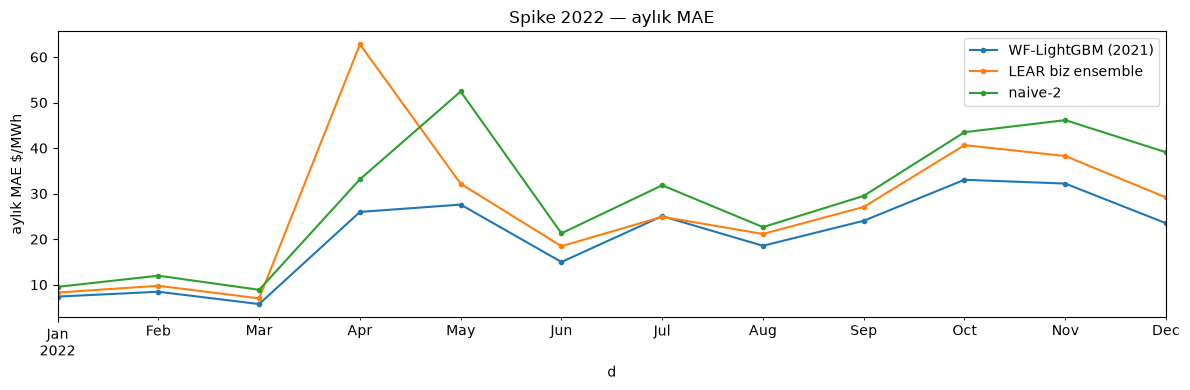

In [7]:
# spike: aylık MAE — WF-LightGBM vs LEAR, tavan dönemi (Mart-Nisan 2022) vurgulu
days = y.index[(y.index >= '2022-01-01') & (y.index <= '2022-12-31')]
mo = pd.Index(days).to_period('M')
fig, ax = plt.subplots(figsize=(12, 4))
plotd = {'WF-LightGBM (2021)': wf.get('spike_tr2021')}
if len(our_spike) == len(SPIKE_CWS): plotd['LEAR biz ensemble'] = ens(our_spike, SPIKE_CWS)
plotd['naive-2'] = n2
for name, d in plotd.items():
    if d is None: continue
    e = np.abs(y.reindex(days).to_numpy() - d.reindex(days).to_numpy()).mean(1)
    pd.Series(e, index=days).groupby(mo).mean().plot(ax=ax, marker='o', ms=3, label=name)
ax.set(ylabel='aylık MAE $/MWh', title='Spike 2022 — aylık MAE'); ax.legend(); plt.tight_layout(); plt.show()


## 3. Sonuç

Test: çöküş 2026-02-01→06-30 (150g), spike 2022 tam yıl (365g). $500 üzeri tahminler elenmiş.

> **Güncelleme (31 Ağu):** WF-LightGBM koşuları `--proxy-from` kaskad bug'ı düzeltildikten
> sonra **proxy'siz** yeniden üretildi (`_v2`). **`LightGBM ensemble (90/150/tüm)`** eklendi
> (C.5.3' — 3 pencere, P50 ortalaması). Detay: `08_collapse_fix_experiments.ipynb`.

| model | çöküş MAE | çöküş rMAE(n2) | çöküş BIAS | çöküş sıfır-saat | spike MAE | spike rMAE(n2) |
|---|---|---|---|---|---|---|
| LightGBM canlı (eğ. 2023) | 10.54 | 0.66 | +3.76 | 3.75 | (kayıt yok) | — |
| WF-LightGBM eğ. 2021 | 10.53 | 0.67 | +3.32 | 3.78 | 20.59 | 0.704 |
| WF-LightGBM eğ. 2023 | 10.49 | 0.66 | +3.44 | 4.15 | — | — |
| **LightGBM ensemble (90/150/tüm)** | **9.62** | **0.609** | **+1.54** | 3.81 | **19.81** | **0.677** |
| LEAR biz TR-4 uyarlanabilir | 10.51 | 0.665 | +0.18 | **1.95** | 23.83 | 0.816 |
| LEAR epftoolbox (Lago-4) | 12.91 | 0.82 | +4.33 | 13.05 pat | — | — |
| naive-3 | 13.05 | 0.83 | +1.24 | 3.34 | 25.90 | 0.885 |

1. **Çöküş — LightGBM ensemble en iyi:** MAE $9.62 (tek-model $10.5 / LEAR $10.5'ten iyi),
   rMAE 0.609, BIAS +$3.76 → **+$1.54**. Çok-pencereli ensemble'ın kısa üyeleri (90g/150g)
   modeli çöküş rejimine kaydırıyor.
2. **Çöküş — sıfır-saatlerde LEAR hâlâ önde:** LEAR $1.95 vs ensemble $3.81. LEAR'ın yuvarlanan
   LASSO kalibrasyonu dip fiyatı daha iyi tutuyor. Fiyat dilimine göre (cell 6): dipte LEAR
   biassız, tepede LightGBM daha iyi.
3. **Çöküş — eğitim penceresi (WF-LightGBM 2021 vs 2023): fark yok** ($10.53 vs $10.49). Canlının
   `TRAINING_DATA_START=2023-01-01` pin'i çöküşü BOZMUYOR — çöküş körlüğü **pencere değil, eski
   rejim eşleşmesi**. C.5.3' bunu birden çok pencere ortalayarak çözüyor.
4. **Spike — WF-LightGBM 2022'de eğitilince yakalıyor:** rMAE(n2) 0.704, MAE $20.59.
   **Ensemble daha da iyi: $19.81 / 0.677** — naive'i net yeniyor. Mimari 2022 kriz rejimini
   kaldırabiliyor; canlı model onu sadece 2023-pin yüzünden görmüyor (gizli risk).
5. **Spike — LEAR (yuvarlanan) vs LightGBM:** LightGBM **kazanıyor** ($19.81 vs $23.83). LEAR'ın
   yuvarlanan kalibrasyonu 2022 oynak fiyatlarını kovalayıp aşırı-uyum yapıyor. Tavan-saatlerde
   naive-3 ($21.96) hepsini yeniyor (tavan kenetli → kalıcılık zor yenilir).

6. **Çıkarım — rejim adaptivitesi:**
   - **Pencere politikası:** spike için kritik (rejimi görmüş olmak), **tek pencere için çöküşte önemsiz.**
   - **Model sınıfı:** çöküşte tek-model başabaş; spike'ta LightGBM > LEAR.
   - **Çok-pencereli ensemble** (C.5.3'): çöküş MAE −$0.9 / BIAS −%59, spike MAE −$0.8. LEAR
     ensemble mantığını LightGBM'e taşıyor — uzun üye yapı, kısa üyeler güncel rejim.
   - **LEAR'ın tek kalan üstünlüğü:** çöküş sıfır-saatleri (yuvarlanan LASSO kalibrasyonu).
     C.5.2 (termal-oran + hidro-net-yük) bunu kısmen kapatıyor (−$0.18), tam değil.
